# Homogeneous elastic 2-D convergence viewer

This lightweight notebook reads the compact 500/375/250 m products generated by `scripts/run_flat_free_surface_convergence.jl`. It does not rerun FD, OPT or SPECFEM2D.

In [1]:
import Pkg
function find_flexopt_root(start=pwd())
    directory = abspath(start)
    while true
        isfile(joinpath(directory, "src", "flexOPT.jl")) && return directory
        parent = dirname(directory)
        parent == directory && break
        directory = parent
    end
    haskey(ENV, "FLEXOPT_ROOT") && return abspath(ENV["FLEXOPT_ROOT"])
    error("Cannot locate flexOPT; set ENV[\"FLEXOPT_ROOT\"]")
end
flexopt_root = find_flexopt_root()
Pkg.activate(flexopt_root)
include(joinpath(flexopt_root, "src", "specfemBenchmark.jl"))
using .specfemBenchmark
using CairoMakie, Statistics, JLD2, JSON
CairoMakie.activate!(type="png")
@show VERSION Threads.nthreads() Base.active_project()


  Activating 

VERSION = v"1.12.6"

project at `~/Documents/Github/flexOPT`



Threads.nthreads() = 8
Base.active_project() = "/Users/nobuaki/Documents/Github/flexOPT/Project.toml"


"/Users/nobuaki/Documents/Github/flexOPT/Project.toml"

## Self-convergence and matched-resolution OPT/SPECFEM comparison

18-element Vector{@NamedTuple{spacing_m::Float64, method::Symbol, component::Symbol, valid_traces::Int64, mean_correlation::Float64, rms_relative_error::Float64}}:
 (spacing_m = 500.0, method = :FD3, component = :x, valid_traces = 10, mean_correlation = 0.8358832880077621, rms_relative_error = 0.5462483298227101)
 (spacing_m = 375.0, method = :FD3, component = :x, valid_traces = 10, mean_correlation = 0.8657674240198029, rms_relative_error = 0.45394388832276095)
 (spacing_m = 250.0, method = :FD3, component = :x, valid_traces = 10, mean_correlation = 1.0, rms_relative_error = 1.7255154402088427e-16)
 (spacing_m = 500.0, method = :OPT3, component = :x, valid_traces = 14, mean_correlation = 0.9912692761014467, rms_relative_error = 0.13150635787141834)
 (spacing_m = 375.0, method = :OPT3, component = :x, valid_traces = 14, mean_correlation = 0.9887422751351487, rms_relative_error = 0.14940652645551267)
 (spacing_m = 250.0, method = :OPT3, component = :x, valid_traces = 14, mean_correlatio

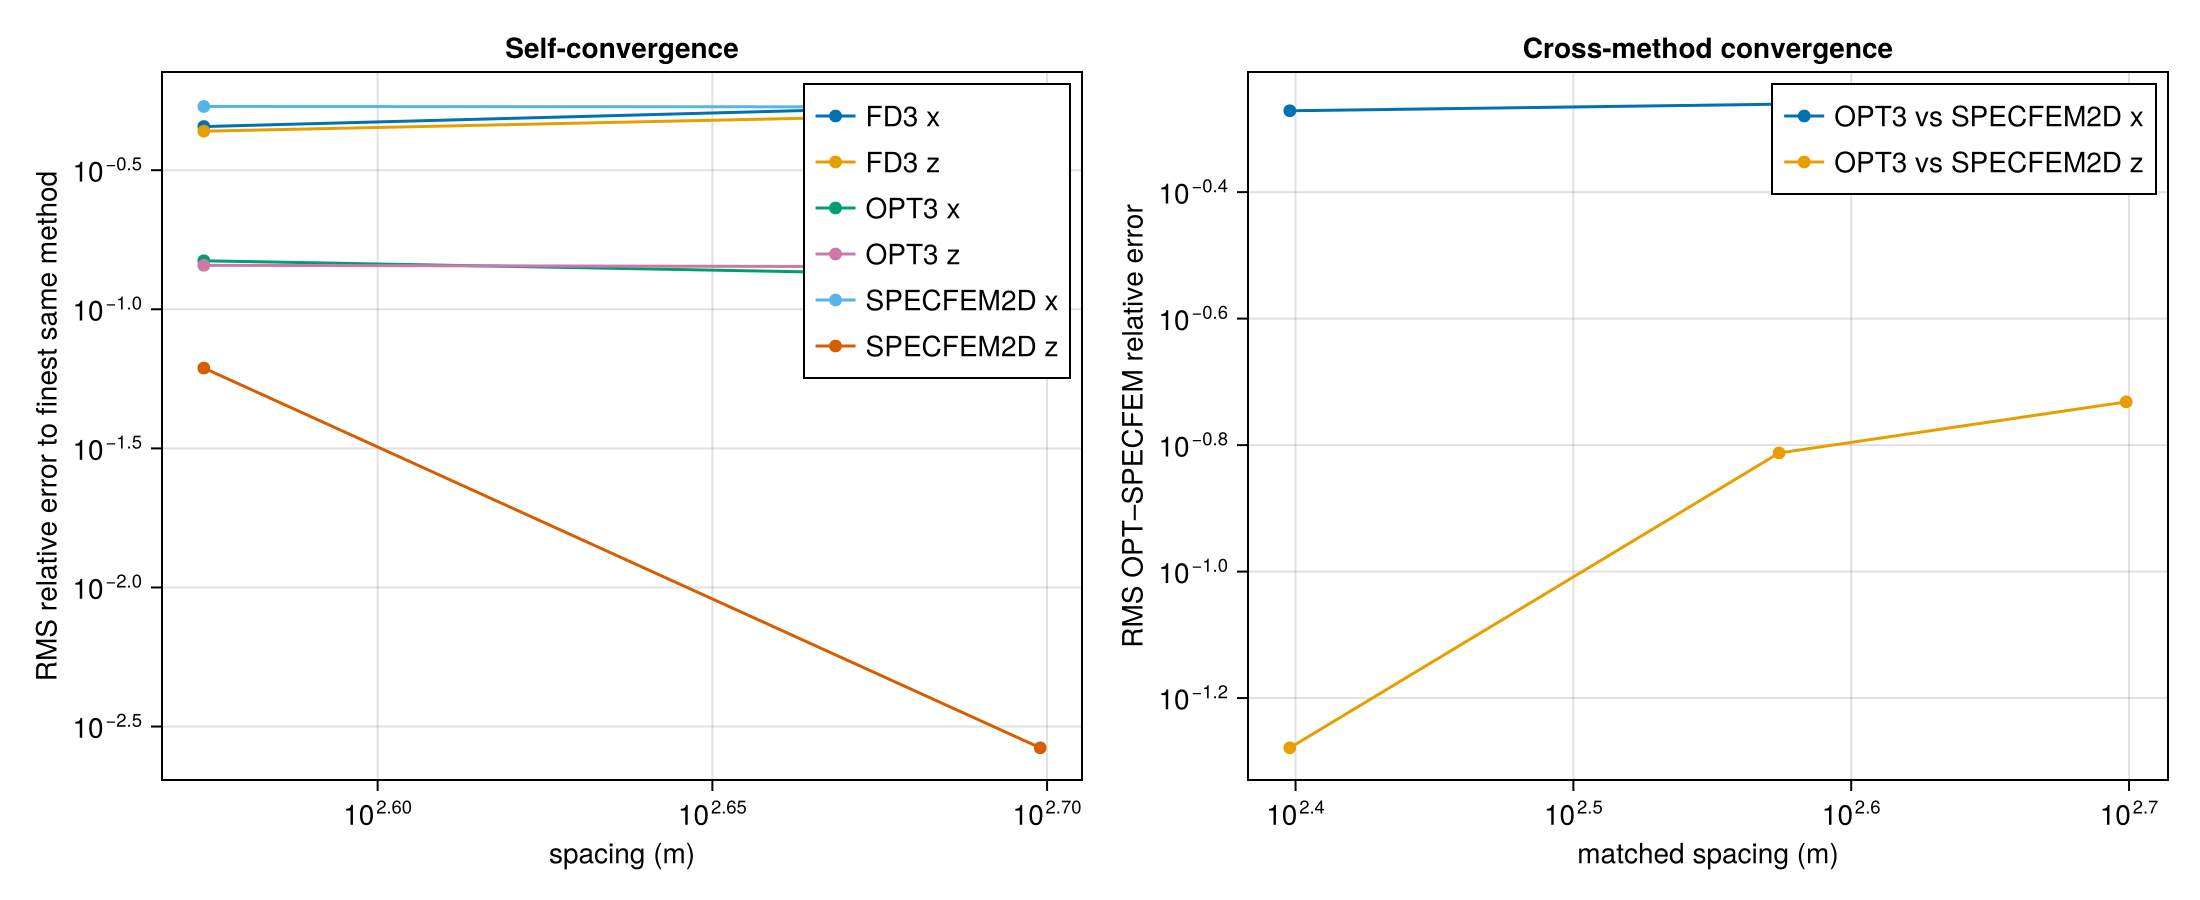

(convergenceFigurePath = "/Users/nobuaki/Documents/Github/flexOPT/data/elastic2d_convergence/homogeneous_flat_free_surface/OPT3_SPECFEM2D_convergence.png", convergenceSummary = [(spacing_m = 500.0, method = :FD3, component = :x, valid_traces = 10, mean_correlation = 0.8358832880077621, rms_relative_error = 0.5462483298227101), (spacing_m = 375.0, method = :FD3, component = :x, valid_traces = 10, mean_correlation = 0.8657674240198029, rms_relative_error = 0.45394388832276095), (spacing_m = 250.0, method = :FD3, component = :x, valid_traces = 10, mean_correlation = 1.0, rms_relative_error = 1.7255154402088427e-16), (spacing_m = 500.0, method = :OPT3, component = :x, valid_traces = 14, mean_correlation = 0.9912692761014467, rms_relative_error = 0.13150635787141834), (spacing_m = 375.0, method = :OPT3, component = :x, valid_traces = 14, mean_correlation = 0.9887422751351487, rms_relative_error = 0.14940652645551267), (spacing_m = 250.0, method = :OPT3, component = :x, valid_traces = 14, me

In [2]:
sourceNotebook = JSON.parsefile(joinpath(flexopt_root, "notebooks",
    "HomogeneousElastic2DBenchmark_FreeSurface.ipynb"))
viewerCell = only(filter(cell -> get(cell, "id", "") ==
    "cross-convergence-viewer", sourceNotebook["cells"]))
Base.include_string(Main, join(viewerCell["source"]),
    "HomogeneousElastic2DBenchmark_FreeSurface:convergence-viewer")


## Reading the result

The vertical component converges strongly between OPT3 and SPECFEM2D. The horizontal component does not: inspect its source convention, receiver component/orientation and P–SV conversion before using SPECFEM as an absolute reference for `uₓ`.